In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

COLAB = False
RANDOM_SEED = 42

DATA_PATH = Path('dados_criminais.csv') if not COLAB else Path('/content/drive/MyDrive/Unisantos/PCG - ML/dados_criminais.csv')
COLUNAS_BASE = [
    'RUBRICA',
    'NOME_MUNICIPIO',
    'BAIRRO',
    'DESCR_TIPOLOCAL',
    'DATA_OCORRENCIA_BO',
    'HORA_OCORRENCIA_BO',
    'DESC_PERIODO',
    'LATITUDE',
    'LONGITUDE',
]

dados_brutos = pd.read_csv(DATA_PATH, usecols=COLUNAS_BASE, low_memory=False)

# quantidade de linhas x colunas
print('shape:', dados_brutos.shape)

# colunas do dataset
print('\ncolunas:', dados_brutos.columns.tolist())

# porcentagem de nulos (NaN) por coluna
print('\nnulos (%):')
print((dados_brutos.isna().mean().sort_values(ascending=False) * 100).round(2).to_string())

# classes mais frequentes na coluna 'RUBRICA'
print('\nclasses principais:')
print(dados_brutos['RUBRICA'].value_counts().head(10).to_string())

shape: (1161132, 9)

colunas: ['NOME_MUNICIPIO', 'DATA_OCORRENCIA_BO', 'HORA_OCORRENCIA_BO', 'DESC_PERIODO', 'DESCR_TIPOLOCAL', 'BAIRRO', 'LATITUDE', 'LONGITUDE', 'RUBRICA']

nulos (%):
DESC_PERIODO          71.62
HORA_OCORRENCIA_BO    28.38
LONGITUDE              7.87
LATITUDE               7.87
BAIRRO                 1.08
DATA_OCORRENCIA_BO     0.00
RUBRICA                0.00
DESCR_TIPOLOCAL        0.00
NOME_MUNICIPIO         0.00

classes principais:
RUBRICA
Furto (art. 155)                                                              636872
Roubo (art. 157)                                                              186613
Lesão corporal (art. 129)                                                     168299
Lesão corporal culposa na direção de veículo automotor (Art. 303)              72722
tráfico drogas (Art.33, caput)                                                 46258
Estupro de vulneravel (art.217-A)                                              11031
ilícito extrapenal (tem

In [2]:
import re
import unicodedata

import holidays


def normalizar_texto(valor: object) -> str:
    # se não houver, troca para 'SEM_INFORMACAO'
    if pd.isna(valor):
        return 'SEM_INFORMACAO'

    # normaliza o texto, limpando caracteres especiais
    texto = unicodedata.normalize('NFKD', str(valor))
    # remove acentos limpando caracteres de composição (ex: '`', '^', '~')
    texto = ''.join(ch for ch in texto if not unicodedata.combining(ch))
    # upppercase, removendo espaços no início e fim
    texto = texto.upper().strip()
    # remove caracteres que não sejam letras, números ou espaços (\s)
    texto = re.sub(r'[^A-Z0-9\s]', ' ', texto)
    # normaliza os espaços, removendo múltiplos espaços por um único espaço
    texto = re.sub(r'\s+', ' ', texto)

    return texto if texto else 'SEM_INFORMACAO'


def padronizar_bairro(valor: object) -> str:
    # normaliza o texto do bairro
    bairro = normalizar_texto(valor)

    if bairro == 'SEM_INFORMACAO':
        return bairro

    # padroniza os prefixos comuns de bairros
    substituicoes = [
        (r'^VL\s+', 'VILA '),
        (r'^VILA\s+', 'VILA '),
        (r'^JD\s+', 'JARDIM '),
        (r'^JARDIM\s+', 'JARDIM '),
        (r'^PQ\s+', 'PARQUE '),
        (r'^PARQUE\s+', 'PARQUE '),
        (r'^CJ\s+', 'CONJUNTO '),
        (r'^CONJUNTO\s+', 'CONJUNTO '),
        (r'^CH\s+', 'CHACARA '),
        (r'^CHACARA\s+', 'CHACARA '),
    ]
    for padrao, substituto in substituicoes:
        bairro = re.sub(padrao, substituto, bairro)

    bairro = re.sub(r'\s+', ' ', bairro).strip()

    return bairro


def extrair_hora(serie: pd.Series) -> pd.Series:
    # ?P<item> permite nomear grupos de regex em python
    hora = serie.astype('string').str.extract(r'(?P<hora>\d{2}):(?P<minuto>\d{2})')['hora']

    # retorna uma coluna com as horas como numero
    return pd.to_numeric(hora, errors='coerce')


def classificar_periodo(hora: pd.Series) -> pd.Series:
    # preenche os valores nulos com -1 para classificar com o default 'SEM_HORA'
    hora_valor = hora.fillna(-1)

    # escolhe o período com base na hora, poderia ser um monte de if também
    condicoes = [
        ((hora_valor >= 0) & (hora_valor <= 5)).to_numpy(),
        ((hora_valor >= 6) & (hora_valor <= 11)).to_numpy(),
        ((hora_valor >= 12) & (hora_valor <= 17)).to_numpy(),
        ((hora_valor >= 18) & (hora_valor <= 23)).to_numpy(),
    ]
    escolhas = ['MADRUGADA', 'MANHA', 'TARDE', 'NOITE']

    # retorna a coluna com os períodos + 'SEM_HORA' para os valores nulos
    return pd.Series(np.select(condicoes, escolhas, default='SEM_HORA'), index=hora.index)


def agrupar_rubricas(df: pd.DataFrame, top_n: int = 5) -> tuple[pd.DataFrame, list[str]]:
    # pega uma lista das top n rubricas
    top_classes = df['RUBRICA'].value_counts().head(top_n).index.tolist()

    # em uma cópia do df, mantem as top n rubricas e agrupa o resto como 'OUTROS'
    df = df.copy()
    df['RUBRICA_ALVO'] = np.where(df['RUBRICA'].isin(top_classes), df['RUBRICA'], 'OUTROS')

    return df, top_classes

# copia o dataset limpando linhas duplicadas
dados = dados_brutos.copy()
dados = dados.drop_duplicates().reset_index(drop=True)

# normaliza colunas textuais
for coluna in ['RUBRICA', 'NOME_MUNICIPIO', 'BAIRRO', 'DESCR_TIPOLOCAL']:
    dados[coluna] = dados[coluna].map(normalizar_texto)

# padroniza o bairro em uma nova coluna 'BAIRRO_PADRAO'
dados['BAIRRO_PADRAO'] = dados['BAIRRO'].map(padronizar_bairro)
# converte a coluna para datetime, caso erro força NaT (Not a Time)
dados['DATA_OCORRENCIA_BO'] = pd.to_datetime(dados['DATA_OCORRENCIA_BO'], errors='coerce')
# extrai a hora como número
dados['HORA_NUM'] = extrair_hora(dados['HORA_OCORRENCIA_BO'])
# classifica o período do dia com base na hora
dados['PERIODO_HORA'] = classificar_periodo(dados['HORA_NUM'])
# extrai o dia da semana (0=segunda, 6=domingo) e o mês como número
dados['DIA_SEMANA'] = dados['DATA_OCORRENCIA_BO'].dt.dayofweek
# extrai o mês como número (1-12)
dados['MES'] = dados['DATA_OCORRENCIA_BO'].dt.month
# classifica se o dia é fim de semana (sábado=5, domingo=6)
dados['FIM_DE_SEMANA'] = dados['DIA_SEMANA'].isin([5, 6]).astype('int8')
# converte as colunas de latitude e longitude para numéricas, forçando erros para NaN
dados['LATITUDE'] = pd.to_numeric(dados['LATITUDE'], errors='coerce')
dados['LONGITUDE'] = pd.to_numeric(dados['LONGITUDE'], errors='coerce')

# puxa os anos do dataset provávelmente apenas 2024, 2025
anos = dados['DATA_OCORRENCIA_BO'].dt.year.dropna().astype(int)
# pega os feriados de SP para os anos do dataset
feriados_sp = set(holidays.Brazil(years=range(anos.min(), anos.max() + 1), subdiv='SP').keys())
# classifica se a data de ocorrência é um feriado, usando o set de feriados para SP
dados['EH_FERIADO'] = dados['DATA_OCORRENCIA_BO'].dt.date.isin(feriados_sp).astype('int8')

# agrupa as rubricas, mantendo as top 5 e agrupando o resto como 'OUTROS'
dados, top_rubricas = agrupar_rubricas(dados, top_n=5)

print('\nDistribuição do alvo agrupado (%):')
print((dados['RUBRICA_ALVO'].value_counts(normalize=True) * 100).round(2).to_string())

print('\nRedução de cardinalidade do bairro:')
print('bairro bruto:', dados['BAIRRO'].nunique())
print('bairro padrao:', dados['BAIRRO_PADRAO'].nunique())


Distribuição do alvo agrupado (%):
RUBRICA_ALVO
FURTO ART 155                                                      54.52
ROUBO ART 157                                                      16.21
LESAO CORPORAL ART 129                                             14.72
LESAO CORPORAL CULPOSA NA DIRECAO DE VEICULO AUTOMOTOR ART 303      6.37
OUTROS                                                              4.37
TRAFICO DROGAS ART 33 CAPUT                                         3.81

Redução de cardinalidade do bairro:
bairro bruto: 33360
bairro padrao: 31429


32,887 linhas (2.9% no dataset apos limpeza).
Top 10 rubricas:
RUBRICA
FURTO ART 155                                                                20093
ROUBO ART 157                                                                 4533
LESAO CORPORAL ART 129                                                        4385
LESAO CORPORAL CULPOSA NA DIRECAO DE VEICULO AUTOMOTOR ART 303                1649
TRAFICO DROGAS ART 33 CAPUT                                                    990
ESTUPRO DE VULNERAVEL ART 217 A                                                255
LOCALIZACAO APREENSAO DE OBJETO                                                153
HOMICIDIO ART 121                                                              150
DROGAS PARA CONSUMO PESSOAL SEM AUTORIZACAO OU EM DESACORDO ART 28 CAPUT       148
ILICITO EXTRAPENAL TEMA 506 STF                                                133

Top 10 tipos de local:
DESCR_TIPOLOCAL
VIA PUBLICA                  23827
RESIDENCIA              

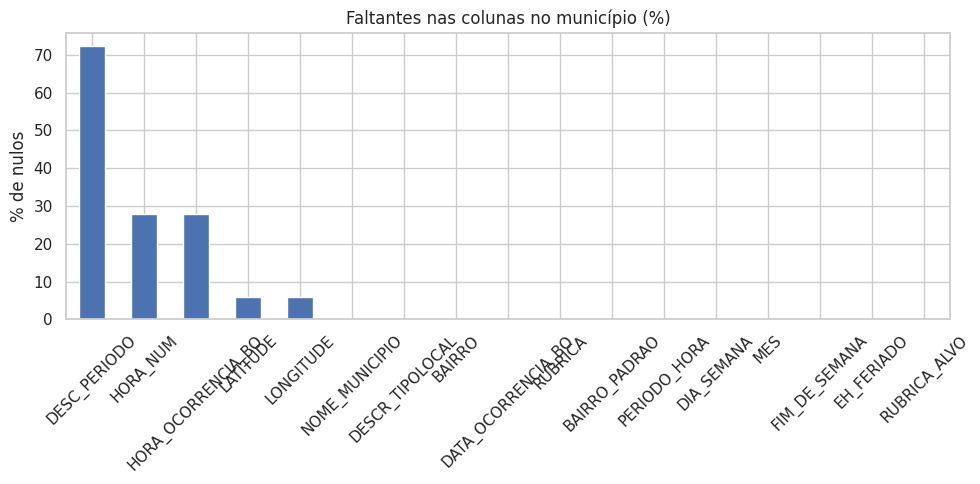

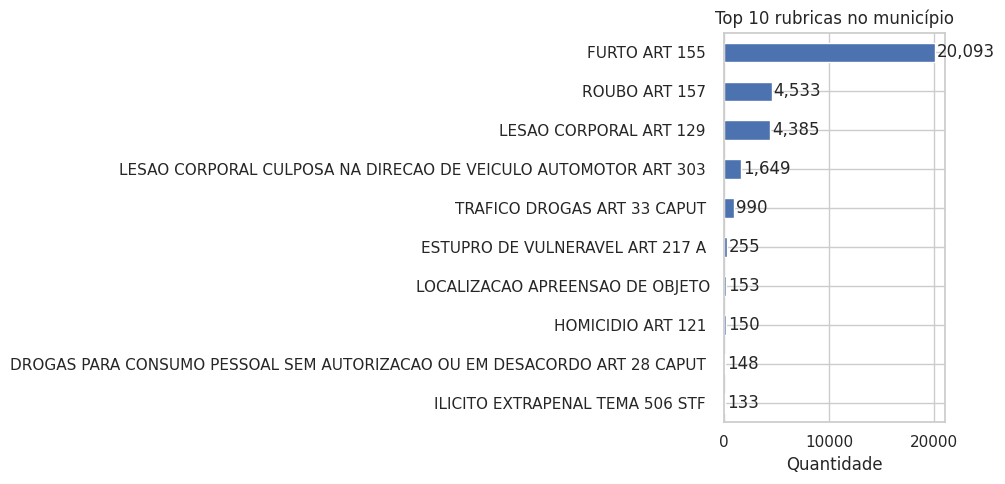

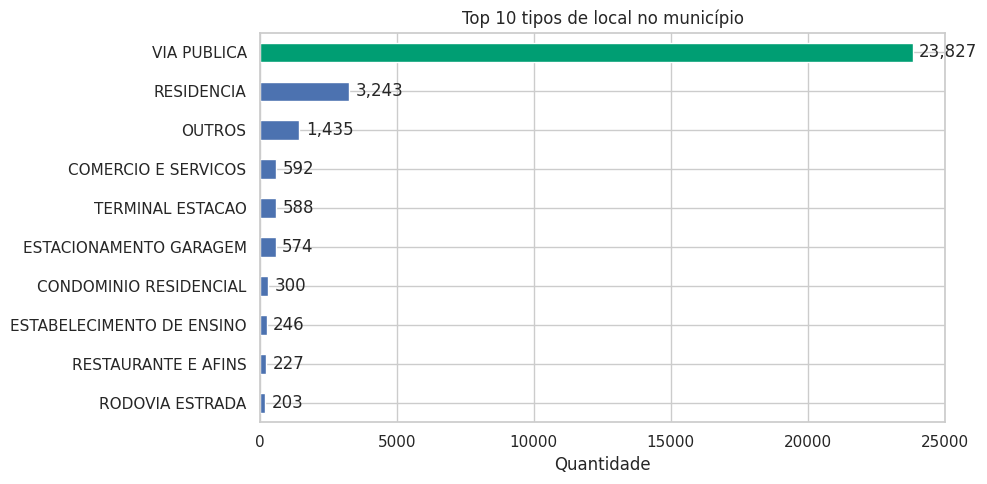

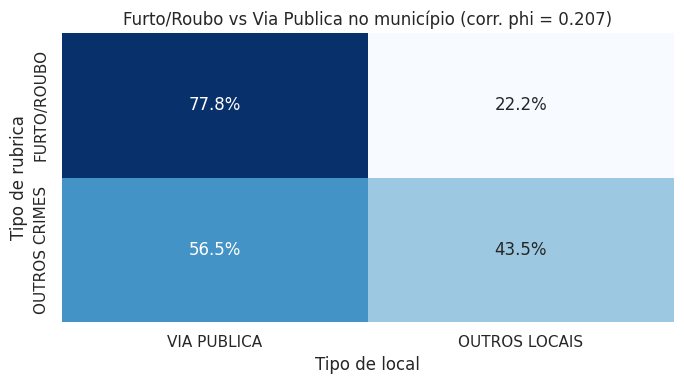

- FURTO ART 155 e ROUBO ART 157 somam 74.9% das ocorrencias no município.
- VIA PUBLICA responde por 72.5% dos registros no município.
- As duas classes de crime e o tipo de local VIA PUBLICA sao extremamente dominantes.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', context='notebook')

# recorte geografico
dados_municipio = dados.loc[dados['NOME_MUNICIPIO'] == 'CAMPINAS'].copy()

print(f'{len(dados_municipio):,} linhas ({len(dados_municipio) / len(dados):.1%} no dataset apos limpeza).')
print('Top 10 rubricas:')
print(dados_municipio['RUBRICA'].value_counts().head(10).to_string())

print('\nTop 10 tipos de local:')
print(dados_municipio['DESCR_TIPOLOCAL'].value_counts().head(10).to_string())

# grafico 1: faltantes apenas
fig, ax = plt.subplots(figsize=(10, 5))
missing_show = dados_municipio.isna().mean().sort_values(ascending=False) * 100
missing_show.plot(kind='bar', ax=ax)
ax.set_title('Faltantes nas colunas no município (%)')
ax.set_xlabel('')
ax.set_ylabel('% de nulos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# grafico 2: classes mais frequentes
furto_roubo = dados_municipio['RUBRICA'].str.contains(r'FURTO ART 155|ROUBO ART 157', na=False)
top_rubricas_municipio = dados_municipio['RUBRICA'].value_counts().head(10).sort_values(ascending=True)
cores_rubricas = ['#D55E00' if rubrica in {'FURTO ART 155', 'ROUBO ART 157'} else '#4C72B0' for rubrica in top_rubricas_municipio.index]
fig, ax = plt.subplots(figsize=(10, 5))
top_rubricas_municipio.plot(kind='barh', ax=ax, color=cores_rubricas)
ax.set_title('Top 10 rubricas no município')
ax.set_xlabel('Quantidade')
ax.set_ylabel('')
for indice, valor in enumerate(top_rubricas_municipio.values):
    ax.text(valor + max(top_rubricas_municipio.values) * 0.01, indice, f'{valor:,}', va='center')
plt.tight_layout()
plt.show()

# grafico 3: tipos de local mais frequentes no município
top_locais_municipio = dados_municipio['DESCR_TIPOLOCAL'].value_counts().head(10).sort_values(ascending=True)
cores_locais = ['#009E73' if local == 'VIA PUBLICA' else '#4C72B0' for local in top_locais_municipio.index]
fig, ax = plt.subplots(figsize=(10, 5))
top_locais_municipio.plot(kind='barh', ax=ax, color=cores_locais)
ax.set_title('Top 10 tipos de local no município')
ax.set_xlabel('Quantidade')
ax.set_ylabel('')
for indice, valor in enumerate(top_locais_municipio.values):
    ax.text(valor + max(top_locais_municipio.values) * 0.01, indice, f'{valor:,}', va='center')
plt.tight_layout()
plt.show()

# grafico 4: relacao entre furto/roubo e via publica
mask_via_publica = dados_municipio['DESCR_TIPOLOCAL'].eq('VIA PUBLICA')
corr_phi = furto_roubo.astype(int).corr(mask_via_publica.astype(int))
tabela_relacao = pd.crosstab(
    np.where(furto_roubo, 'FURTO/ROUBO', 'OUTROS CRIMES'),
    np.where(mask_via_publica, 'VIA PUBLICA', 'OUTROS LOCAIS'),
    normalize='index',
).reindex(index=['FURTO/ROUBO', 'OUTROS CRIMES'], columns=['VIA PUBLICA', 'OUTROS LOCAIS']).fillna(0)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(tabela_relacao, annot=True, fmt='.1%', cmap='Blues', cbar=False, ax=ax)
ax.set_title(f'Furto/Roubo vs Via Publica no município (corr. phi = {corr_phi:.3f})')
ax.set_xlabel('Tipo de local')
ax.set_ylabel('Tipo de rubrica')
plt.tight_layout()
plt.show()

print(f"- FURTO ART 155 e ROUBO ART 157 somam {furto_roubo.mean() * 100:.1f}% das ocorrencias no município.")
print(f"- VIA PUBLICA responde por {mask_via_publica.mean() * 100:.1f}% dos registros no município.")
print('- As duas classes de crime e o tipo de local VIA PUBLICA sao extremamente dominantes.')


=== Município - VIA_PUBLICA vs RESTO ===
accuracy: 0.7145
balanced_accuracy: 0.7257
f1_macro: 0.7144
f1_weighted: 0.7147

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.63      0.81      0.71       719
           1       0.82      0.64      0.72       934

    accuracy                           0.71      1653
   macro avg       0.72      0.73      0.71      1653
weighted avg       0.74      0.71      0.71      1653

roc_auc: 0.7916


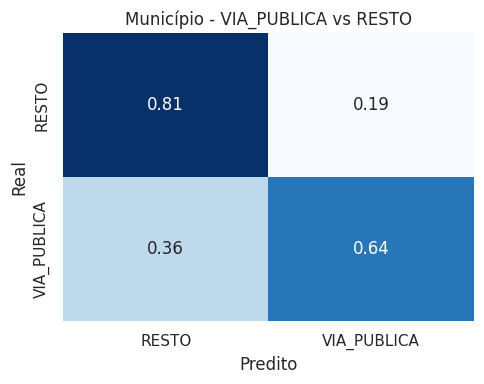


=== (BASELINE) Município - VIA_PUBLICA vs RESTO ===
accuracy: 0.5045
balanced_accuracy: 0.4971
f1_macro: 0.497
f1_weighted: 0.505

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.43      0.44      0.44       719
           1       0.56      0.55      0.56       934

    accuracy                           0.50      1653
   macro avg       0.50      0.50      0.50      1653
weighted avg       0.51      0.50      0.51      1653

roc_auc: 0.4971


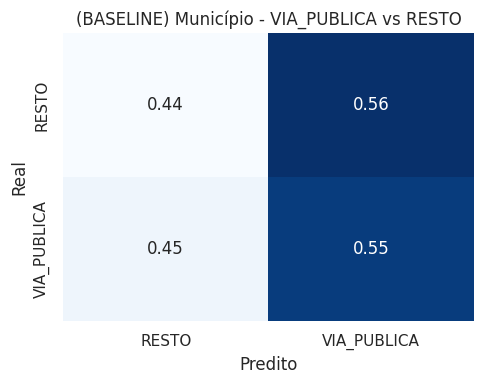

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# setup do tema para os gráficos
sns.set_theme(style='whitegrid', context='notebook')

# remove linhas sem descrição do tipo de local
dados_municipio = dados_municipio.dropna(subset=['DESCR_TIPOLOCAL']).reset_index(drop=True)
# remove os furtos e roubos, são os crimes mais presentes e dominam o modelo caso entrem
dados_municipio = dados_municipio.loc[
    ~dados_municipio['RUBRICA'].str.contains(
        r'FURTO ART 155|ROUBO ART 157',
        na=False
    )
].reset_index(drop=True)
# transforma o tipo de local em binário VIA_PUBLICA vs RESTO
dados_municipio['ALVO_VIA_PUBLICA'] = (dados_municipio['DESCR_TIPOLOCAL'] == 'VIA PUBLICA').astype(int)

features_categoricas = ['RUBRICA', 'BAIRRO_PADRAO', 'PERIODO_HORA']
features_numericas = ['DIA_SEMANA', 'MES', 'FIM_DE_SEMANA', 'EH_FERIADO']

preprocessador = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline(
                steps=[
                    # preencher valores faltantes usando a categoria mais frequente
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    # transforma categorias em colunas binárias, ignorando categorias desconhecidas e com frequência mínima de 50, usando matriz esparsa
                    (
                        'onehot',
                        OneHotEncoder(
                            handle_unknown='ignore',
                            min_frequency=50,
                            sparse_output=True,
                        ),
                    ),
                ]
            ),
            features_categoricas,
        ),
        (
            'num',
            Pipeline(
                steps=[
                    # preencher valores faltantes usando a mediana da coluna
                    ('imputer', SimpleImputer(strategy='median')),
                    # padroniza os valores numéricos sem centralizar pela média
                    ('scaler', StandardScaler(with_mean=False)),
                ]
            ),
            features_numericas,
        ),
    ]
)

modelo = LogisticRegression(
    # saga para sparse
    solver='saga',
    # limitar as iterações
    max_iter=4000,
    # balanceie as classes
    class_weight='balanced',
    # seed para reprodutibilidade
    random_state=RANDOM_SEED,
)

# monta pipeline do modelo de regressão logística
pipeline_modelo = Pipeline(
    steps=[
        ('preprocessador', preprocessador),
        ('modelo', modelo),
    ]
)

# monta pipeline do modelo baseline dummy, que faz previsões aleatórias balanceadas, para comparação
pipeline_base = Pipeline(
    steps=[
        ('preprocessador', preprocessador),
        ('modelo', DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)),
    ]
)


def avaliar_alvo(df: pd.DataFrame, descricao: str, dummy = False) -> Pipeline:
    # dropa linhas sem valor no alvo
    base = df[features_categoricas + features_numericas + ['ALVO_VIA_PUBLICA']].dropna(subset=['ALVO_VIA_PUBLICA']).reset_index(drop=True)
    # separa as features do alvo
    X = base[features_categoricas + features_numericas]
    y = base['ALVO_VIA_PUBLICA']

    X_treino, X_teste, y_treino, y_teste = train_test_split(
        X,
        y,
        # 80% treino 20% teste
        test_size=0.2,
        # reprodutibilidade
        random_state=RANDOM_SEED,
        # mantém a proporção das classes no treino e teste
        stratify=y,
    )

    # seleciona o modelo de regressão logística ou o baseline
    pipe = pipeline_base if dummy else pipeline_modelo

    # treina o modelo
    pipe.fit(X_treino, y_treino)

    # faz previsões no conjunto de teste para classes
    pred = pipe.predict(X_teste)

    print(f'\n=== {descricao} ===')
    # acurácia geral do modelo (acertos/total)
    print('accuracy:', round(accuracy_score(y_teste, pred), 4))
    # acurácia levando em conta em conta o desequilíbrio das classes
    print('balanced_accuracy:', round(balanced_accuracy_score(y_teste, pred), 4))
    # média do f1-score de cada classe, sem ponderação
    print('f1_macro:', round(f1_score(y_teste, pred, average='macro'), 4))
    # f1-score ponderado pela quantidade de amostras de cada classe
    print('f1_weighted:', round(f1_score(y_teste, pred, average='weighted'), 4))

    print('\nRelatório de classificação:')
    print(classification_report(y_teste, pred, zero_division=0))

    # pega as classes do modelo
    classes = list(pipe.named_steps['modelo'].classes_)
    # pega o index da classe positiva (1)
    pos_idx = classes.index(1)

    # faz as previsões das probabilidades de cada classe no conjunto de teste
    proba = pipe.predict_proba(X_teste)

    # pega as probabilidades da classe positiva como uma lista
    proba_pos = proba[:, pos_idx]

    # calcula roc_auc usando as probabilidades da classe positiva e o alvo real
    print('roc_auc:', round(roc_auc_score(y_teste, proba_pos), 4))

    # plota a matriz de confusão normalizada, mostrando a proporção de acertos e erros para cada classe
    matriz = confusion_matrix(y_teste, pred, normalize='true')
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        matriz,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        ax=ax,
        cbar=False,
        xticklabels=['RESTO', 'VIA_PUBLICA'],
        yticklabels=['RESTO', 'VIA_PUBLICA'],
    )
    ax.set_title(descricao)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    plt.tight_layout()
    plt.show()

    return pipe

modelo = avaliar_alvo(
    dados_municipio,
    'Município - VIA_PUBLICA vs RESTO'
)

baseline = avaliar_alvo(
    dados_municipio,
    '(BASELINE) Município - VIA_PUBLICA vs RESTO',
    dummy=True
)